In [1]:
%load_ext autoreload
%autoreload 2
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

In [2]:
from gates.plotting import plot_fp_predictions

In [5]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

In [54]:
preds = xr.open_dataset("/user/work/ef17148/GCN/graphnet/graphnet_LPDM_emulator/test_predictions/fixedmet_gpu_freq3_PixelWeightedMSELoss_a1_landcover/predictions/predictions_2016_12.nc")

[1, 1]


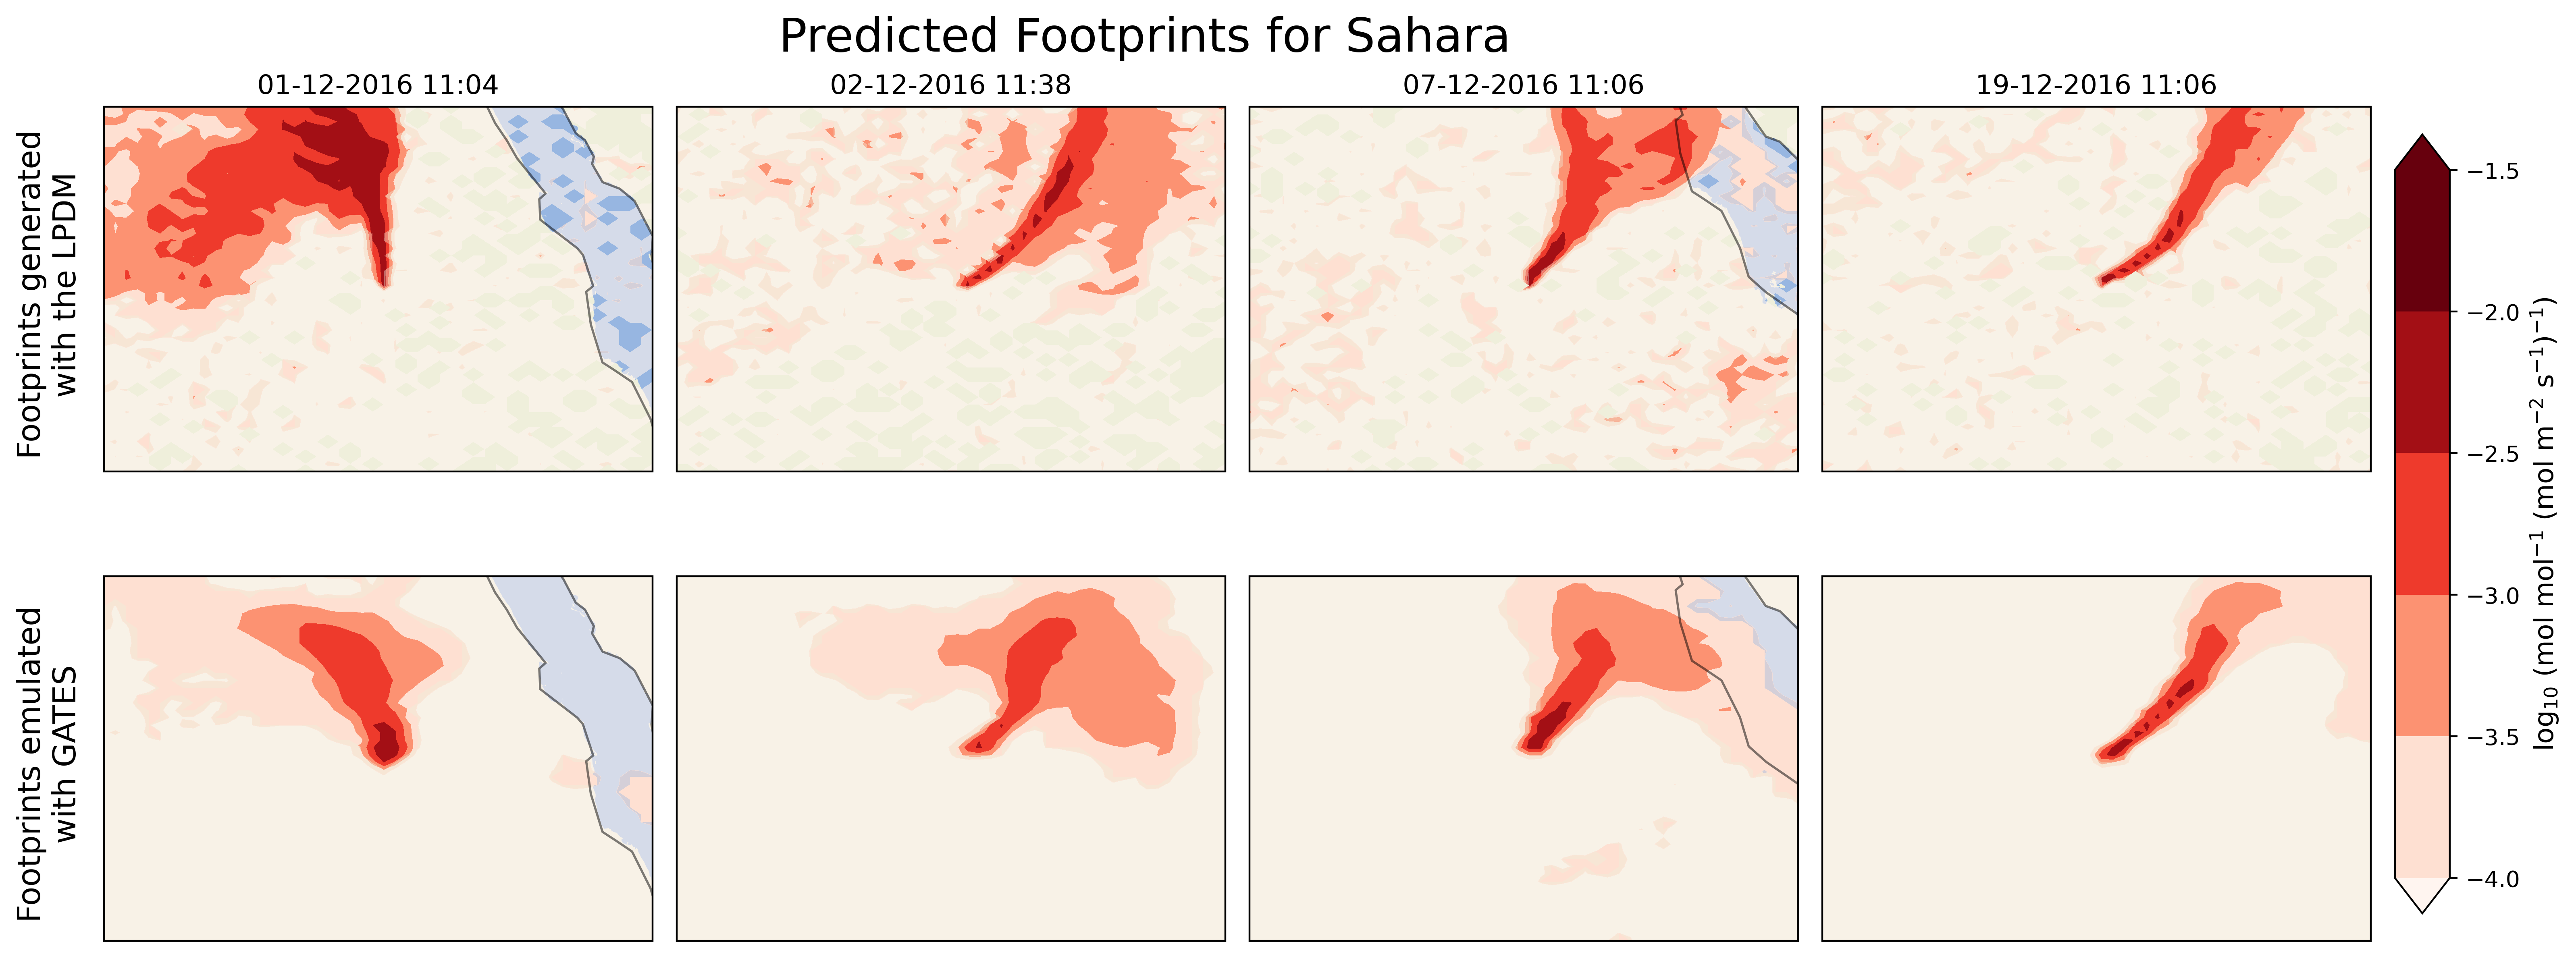

In [56]:
## plot footprints with this function. specify the index of the footprints to plot as a list in idxs_list (the length can be variable). Contour is recommended, you can override the levels and the min/max with levels and vmin_vmax arguments. The threshold parameter is used in the contour - anything below the threshold is set as a lighter, see-through colour. 
plot_fp_predictions(preds, idxs_list=[10, 100, 300, 800], contour=True, thres=1e-4, fig_title="Predicted Footprints for Sahara", which_dataspace="original")

In [13]:
from gates.data.load_data import load_flux_data, cut_flux_data
from gates.evaluation.post_processing import threshold_fps
import gates.evaluation.metrics as gates_metrics

In [57]:
# threshold the predicted footprints to a determined threshold  
preds = threshold_fps(preds, threshold=1.75e-5)

[1, 1]


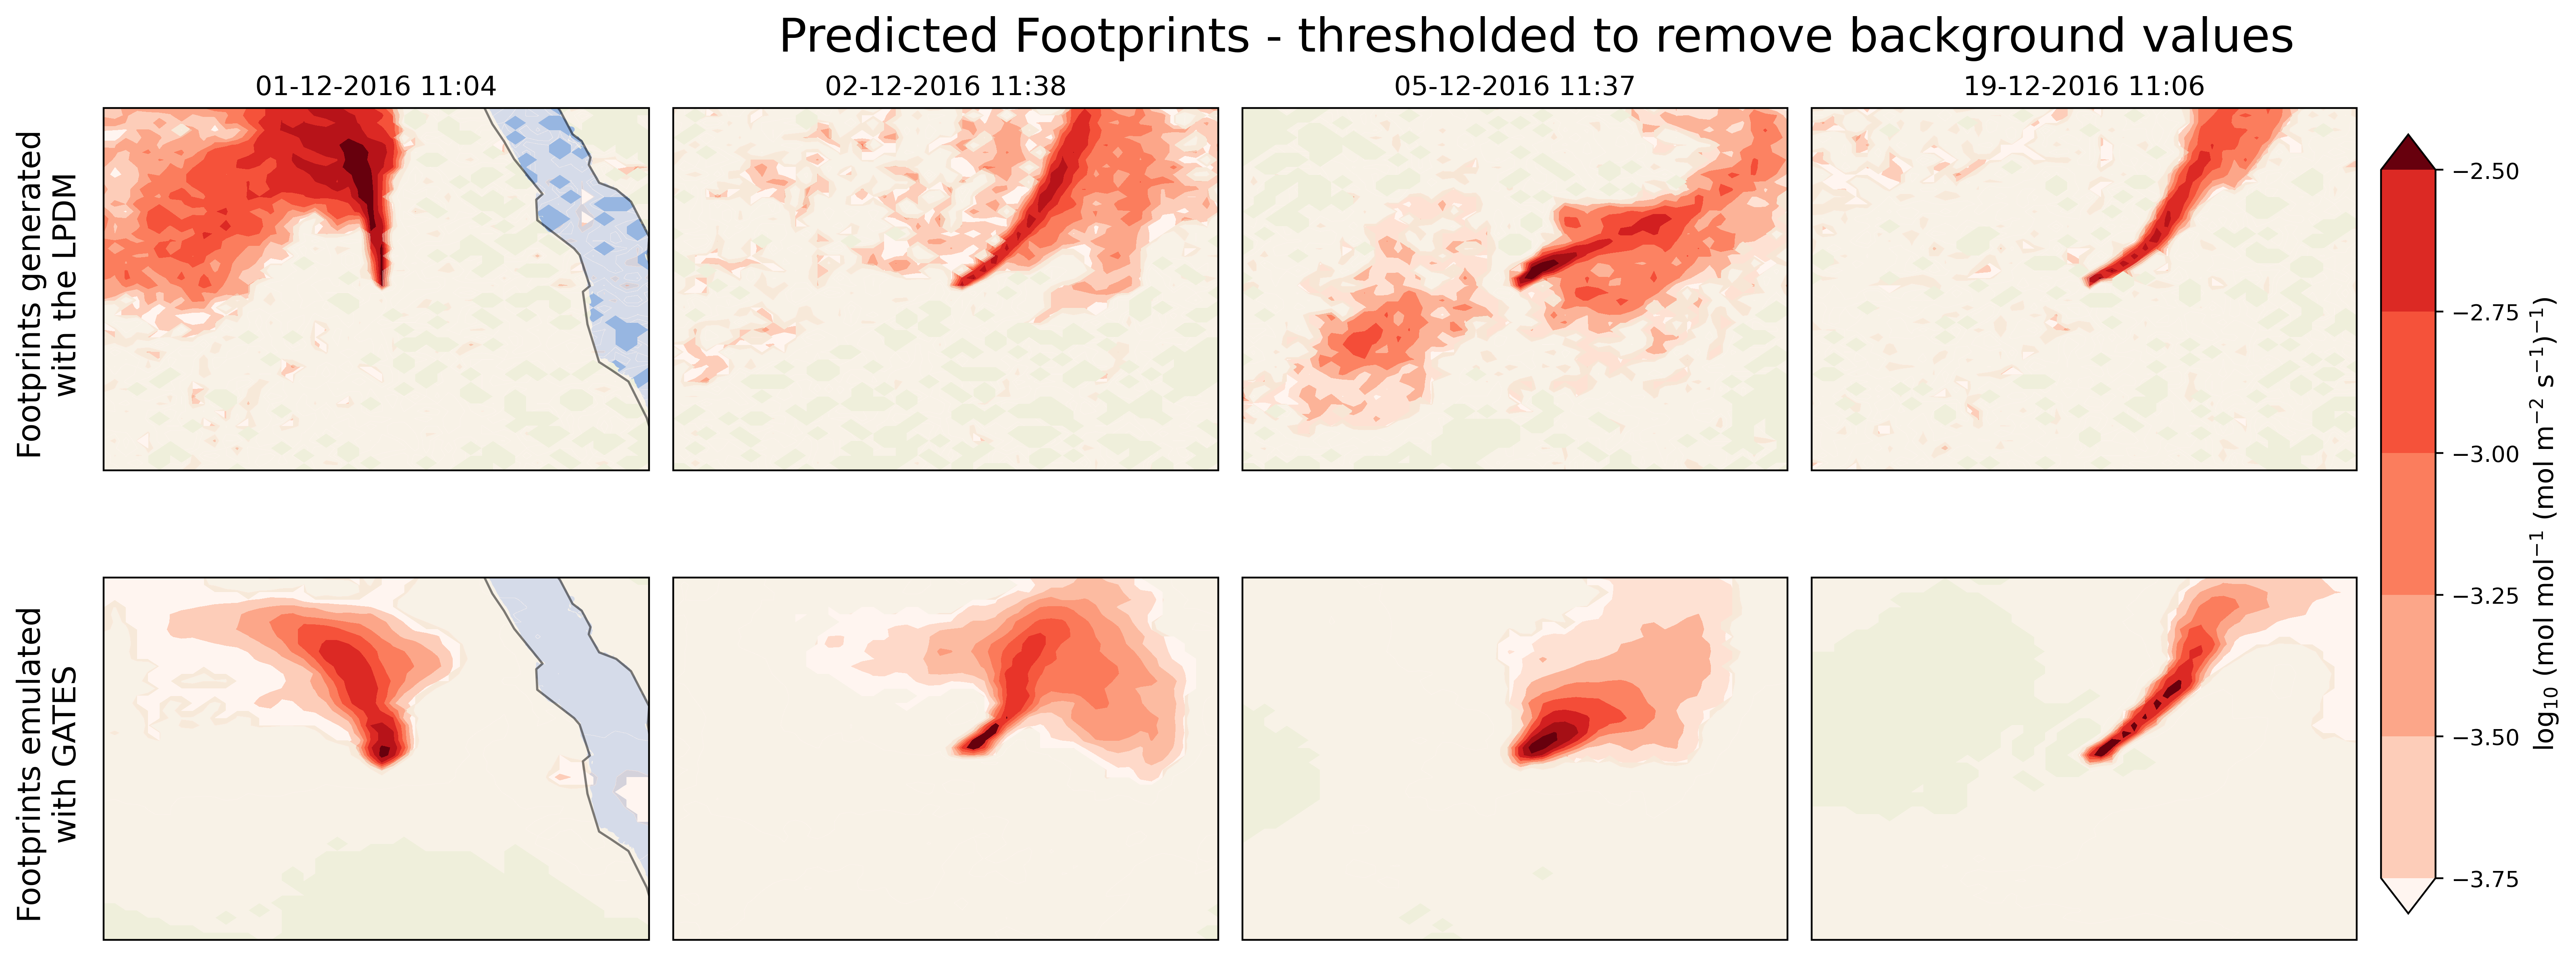

In [59]:
# and plot them
plot_fp_predictions(preds, idxs_list=[10, 100, 200, 800], contour=True, thres=1e-4, fig_title="Predicted Footprints - thresholded to remove background values", which_dataspace="thresholded")

In [30]:
# you can plot some stats about the footprints with
gates_metrics.compute_footprint_metrics(preds["fp_original"], preds["fp_pred_thres"], ignore_mask=preds["fp_nan_mask"])

{'iou': 0.6813649722854264,
 'mse': 3.5517493301995273e-07,
 'mae': 0.00016755287651903927,
 'nmae': 0.8864462971687317,
 'corrcoef': 0.6554632921502989,
 'corrcoef_log': 0.5404692415459786,
 'bias': -7.736408588243648e-05}

In [32]:
import gates

In [40]:
# you can also load the fluxes, crop them and calculate the mole fractions
ems = load_flux_data("NORTHAFRICA", year=2016)
cropped_fluxes, _ = cut_flux_data(ems, preds, size=50)
mfs = gates_metrics.calculate_mfs(preds[["fp_original", "fp_pred_thres"]], cropped_fluxes, transform_factor=1e9)

Loading flux data from /group/chem/acrg/LPDM/emissions/NORTHAFRICA/ch4_NORTHAFRICA_2016.nc
cut_flux_data: WARNING — flux resolution (0.2340, 0.3520) differs from fp resolution (1.0000, 1.0000). Spatial alignment may be off.
Using lat_coords and lon_coords to cut flux data, assuming they are aligned and have the same resolution as the flux data.


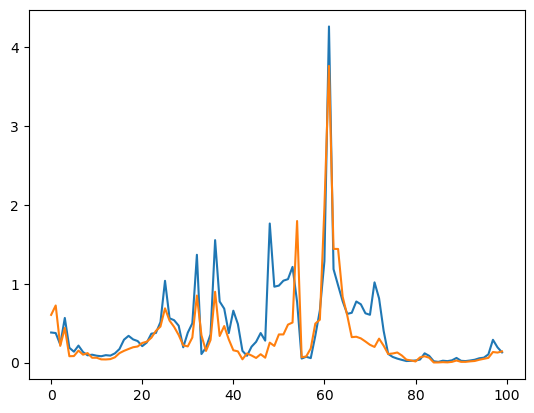

In [ ]:
# we can plot these (new functions coming)
plt.plot(mfs["mf_original"].isel(time=slice(0,100)).values)
plt.plot(mfs["mf_pred_thres"].isel(time=slice(0,100)).values)

In [45]:
# and get some metrics
gates_metrics.compute_mfs_metrics(mfs["mf_original"], mfs["mf_pred_thres"])

{'corrcoef': 0.7997281586305034,
 'mae': 0.3363400995731354,
 'mean_bias': -0.2613910138607025,
 'true_mean': 0.7008071541786194,
 'predicted_mean': 0.4394161105155945,
 'r2_score': 0.5422990322113037}

In [ ]:
# and compute metrics using uniform fluxes
gates_metrics.compute_static_mf_metrics(preds["fp_original"], preds["fp_pred_thres"], ignore_mask=preds["fp_nan_mask"])

{'uniform': {'corrcoef': 0.662377000764233,
  'mae': 0.20506483234041042,
  'mean_bias': -0.1930486263981564,
  'true_mean': 0.5005686759948731,
  'predicted_mean': 0.30752004959671664,
  'r2_score': -0.1495677476362991},
 'checkerboard': {'corrcoef': 0.6641080550544338,
  'mae': 0.10131603726918854,
  'mean_bias': -0.09510897798840574,
  'true_mean': 0.24953370094299315,
  'predicted_mean': 0.15442472295458742,
  'r2_score': -0.1299293924477385},
 'checkerboard_10': {'corrcoef': 0.5879137280236607,
  'mae': 0.1045702502375363,
  'mean_bias': -0.09873520504572611,
  'true_mean': 0.22677549123764038,
  'predicted_mean': 0.12804028619191427,
  'r2_score': -0.29310108975733895},
 'checkerboard_25': {'corrcoef': 0.740069475387015,
  'mae': 0.09323803794650871,
  'mean_bias': -0.07748282112802088,
  'true_mean': 0.1912314236164093,
  'predicted_mean': 0.11374860248838843,
  'r2_score': 0.31260759760973933}}

In [52]:
preds = xr.open_dataset("/user/work/ef17148/GCN/graphnet/graphnet_LPDM_emulator/test_predictions/fixedmet_gpu_freq3_PixelWeightedMSELoss_a1_landcover/predictions_BRAZIL/predictions_2016_11.nc")

[1, 1]


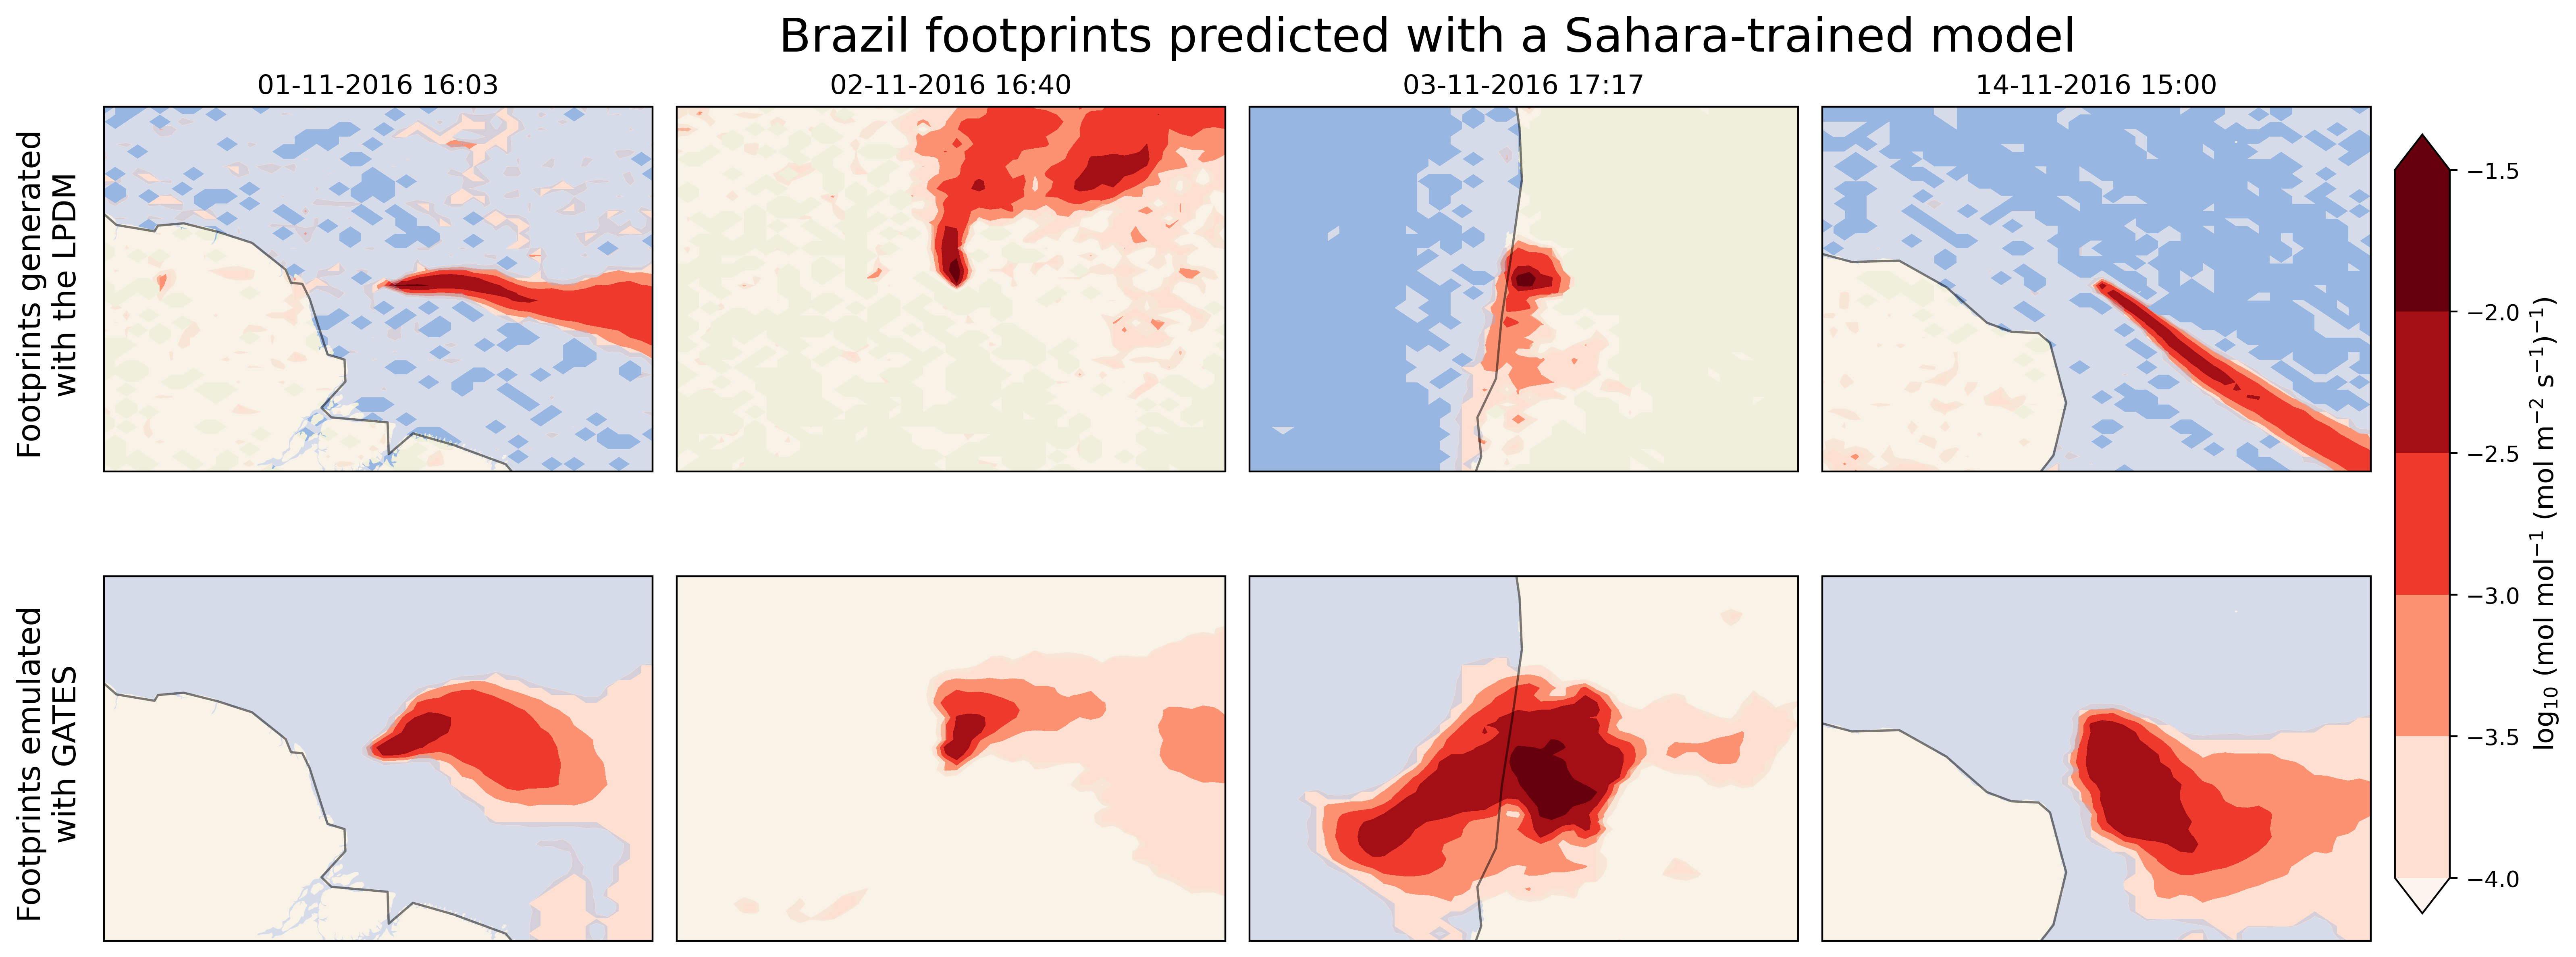

In [53]:
# and plot them
plot_fp_predictions(preds, idxs_list=[10, 100, 200, 800], contour=True, thres=1e-4, fig_title="Brazil footprints predicted with a Sahara-trained model", which_dataspace="original")